In [167]:
import xarray as xr
import matplotlib.pyplot as plt
import rasterio
from rasterio.transform import from_origin
import numpy as np

In [75]:
path = 'data/current_data/test2/SMOC_20260204_R20260218.nc'

In [ ]:
ds = xr.open_dataset(path).sel(longitude=slice(26,28), latitude=slice(-35.5, -33.5), time='2026-02-04T04:30:00.000000000').load()
ds

<xarray.Dataset> Size: 20kB
Dimensions:    (depth: 1, latitude: 25, longitude: 25)
Coordinates:
  * depth      (depth) float32 4B 0.494
  * latitude   (latitude) float32 100B -35.5 -35.42 -35.33 ... -33.58 -33.5
  * longitude  (longitude) float32 100B 26.0 26.08 26.17 ... 27.83 27.92 28.0
    time       datetime64[ns] 8B 2026-02-04T04:30:00
Data variables:
    utotal     (depth, latitude, longitude) float32 2kB -0.3652 ... -1.477
    vtotal     (depth, latitude, longitude) float32 2kB 0.02637 ... -1.599
    utide      (depth, latitude, longitude) float32 2kB 0.003906 ... 0.0
    vtide      (depth, latitude, longitude) float32 2kB -0.001953 ... -0.00293
    uo         (depth, latitude, longitude) float32 2kB -0.2988 ... -1.417
    vo         (depth, latitude, longitude) float32 2kB 0.04785 ... -1.566
    vsdx       (depth, latitude, longitude) float32 2kB -0.07031 ... -0.05957
    vsdy       (depth, latitude, longitude) float32 2kB -0.01953 ... -0.03027
Attributes:
    producer:                      CMEMS - Global Monitoring and Forecasting ...
    title:                         hourly mean merged surface currents from o...
    area:                          GLOBAL
    quality_information_document:  http://marine.copernicus.eu/documents/QUID...
    Conventions:                   CF-1.6
    credit:                        E.U. Copernicus Marine Service Information...
    contact:                       servicedesk.cmems@mercator-ocean.eu
    references:                    http://marine.copernicus.eu
    source:                        MERCATOR GLO12, mfwamglo, FES2014
    licence:                       http://marine.copernicus.eu/services-portf...
    product_user_manual:           http://marine.copernicus.eu/documents/PUM/...
    institution:                   MERCATOR OCEAN

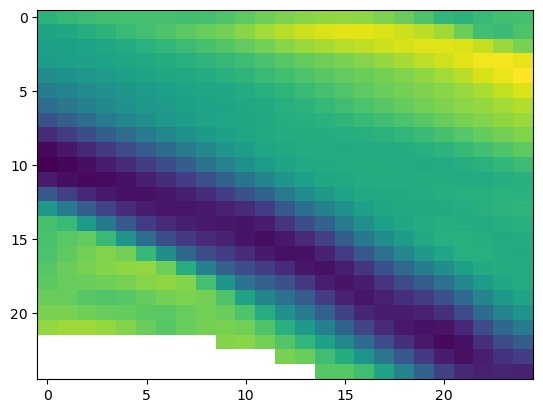

In [119]:
plt.imshow(ds['uo'].values.squeeze(), aspect='auto')

In [120]:
transform = from_origin(
    west=ds.longitude.min().item(),
    north=ds.latitude.min().item(),
    xsize=(ds.longitude[1] - ds.longitude[0]).item(),
    ysize=(ds.latitude[0] - ds.latitude[1]).item(),
)

In [134]:
data = ds[['uo', 'vo']].to_array().values.squeeze()

with rasterio.open(
    "data/current_data/test2/ocean_current.tif",
    "w",
    driver="GTiff",
    height=data.shape[1],
    width=data.shape[2],
    count=data.shape[0],
    dtype=data.dtype,
    crs="EPSG:4326",  # or your CRS
    transform=transform,
) as dst:
    dst.write(data)

In [156]:
src = rasterio.open('data/current_data/test2/ocean_current.tif')
uo =  src.read(1)
vo = src.read(2)
uo[uo==-1000]=np.nan
vo[vo==-1000]=np.nan

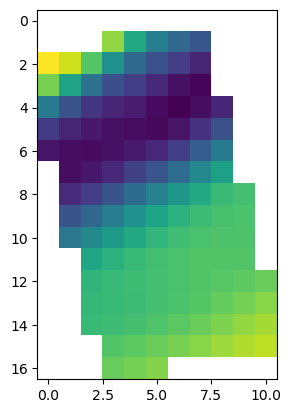

In [157]:
plt.imshow(uo)

In [161]:
def expected_doppler_biomass(u_e, u_n):#, heading_deg, incidence_deg, freq_hz=435e6):
    c = 299792458.0
    lam = c / 435e6

    H = np.deg2rad(-12.9071172)
    th = np.deg2rad(26.9803)

    # right-looking radar
    g_e = np.cos(H)
    g_n = -np.sin(H)

    u_look = u_e * g_e + u_n * g_n
    v_los = u_look * np.sin(th)
    f_d = -2.0 * v_los / lam
    return f_d

In [162]:
exp = expected_doppler_biomass(uo, vo)

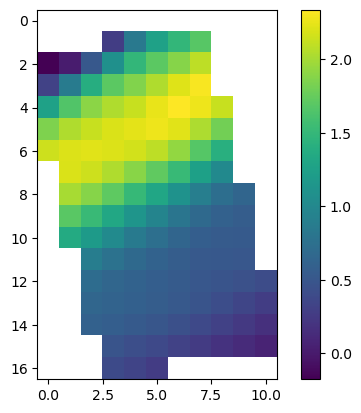

In [166]:
plt.imshow(exp)
plt.colorbar()